<a href="https://colab.research.google.com/github/cedaco/RGV-Obesity-Project/blob/main/Hidalgo_Obesity_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [6]:
df = pd.read_csv("https://data.cdc.gov/resource/i46a-9kgh.csv?$limit=50000")
cols_of_interest = [
    'stateabbr',
    'countyname',
    'totalpopulation',
    'obesity_crudeprev',
    'diabetes_crudeprev',
    'lpa_crudeprev',
    'access2_crudeprev',
    'bphigh_crudeprev',
    'csmoking_crudeprev',
    'sleep_crudeprev',
    'depression_crudeprev',
    'cholscreen_crudeprev',
]
df = df[cols_of_interest]
df = df.dropna()
rgv = df[(df['stateabbr'] == 'TX') & (df['countyname'].isin(['Hidalgo', 'Cameron']))]

In [7]:
# National and Texas averages
national_avg = df.mean(numeric_only=True)
texas_avg = df[df['stateabbr'] == 'TX'].mean(numeric_only=True)

comparison = pd.DataFrame({
    'Hidalgo': rgv[rgv['countyname'] == 'Hidalgo'].mean(numeric_only=True),
    'Cameron': rgv[rgv['countyname'] == 'Cameron'].mean(numeric_only=True),
    'Texas Avg': texas_avg,
    'National Avg': national_avg
}).drop('totalpopulation')

print(comparison.round(2))


                      Hidalgo  Cameron  Texas Avg  National Avg
obesity_crudeprev        44.2     40.3      37.42         37.42
diabetes_crudeprev       17.4     18.3      14.62         13.64
lpa_crudeprev            37.5     36.9      31.28         28.45
access2_crudeprev        37.4     35.9      20.36         11.14
bphigh_crudeprev         33.4     34.0      37.66         38.72
csmoking_crudeprev       13.3     13.0      14.70         15.82
sleep_crudeprev          40.4     39.8      38.24         35.79
depression_crudeprev     20.2     18.9      22.11         22.90
cholscreen_crudeprev     80.2     82.4      84.66         85.44


In [8]:
# Where do RGV counties rank nationally for obesity?
df_ranked = df.copy()
df_ranked['obesity_rank'] = df_ranked['obesity_crudeprev'].rank(ascending=False)
df_ranked['obesity_percentile'] = df_ranked['obesity_crudeprev'].rank(pct=True) * 100

rgv_ranks = df_ranked[df_ranked['countyname'].isin(['Hidalgo', 'Cameron']) & (df_ranked['stateabbr'] == 'TX')]
print(rgv_ranks[['countyname', 'obesity_crudeprev', 'obesity_rank', 'obesity_percentile']].round(2))

     countyname  obesity_crudeprev  obesity_rank  obesity_percentile
636     Cameron               40.3         782.0               73.58
1852    Hidalgo               44.2         153.5               94.84


In [9]:
hidalgo_obesity = df[(df['stateabbr'] == 'TX') & (df['countyname'] == 'Hidalgo')]['obesity_crudeprev'].values[0]
texas_obesity = df[df['stateabbr'] == 'TX']['obesity_crudeprev'].dropna()
national_obesity = df['obesity_crudeprev'].dropna()

# Hidalgo vs Texas
t_stat, p_value = stats.ttest_1samp(texas_obesity, hidalgo_obesity)
print(f"Hidalgo vs Texas:    t={t_stat:.3f}, p={p_value:.4f}")

# Hidalgo vs National
t_stat, p_value = stats.ttest_1samp(national_obesity, hidalgo_obesity)
print(f"Hidalgo vs National: t={t_stat:.3f}, p={p_value:.4f}")

Hidalgo vs Texas:    t=-37.246, p=0.0000
Hidalgo vs National: t=-77.495, p=0.0000


LINEAR REGRESSION: PREDICTING HIDALGO OBESITY VS ACTUAL

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Features and target
X = df[['diabetes_crudeprev', 'lpa_crudeprev', 'access2_crudeprev',
        'bphigh_crudeprev', 'csmoking_crudeprev', 'sleep_crudeprev',
        'depression_crudeprev', 'cholscreen_crudeprev']]
y = df['obesity_crudeprev']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred)**0.5:.4f}")

# Coefficients
coef_df = pd.DataFrame({'Variable': X.columns, 'Coefficient': model.coef_}).sort_values('Coefficient', ascending=False)
print(coef_df.round(4))

R² Score: 0.6595
RMSE: 2.8374
               Variable  Coefficient
1         lpa_crudeprev       0.3793
4    csmoking_crudeprev       0.2465
3      bphigh_crudeprev       0.2390
5       sleep_crudeprev       0.0876
6  depression_crudeprev      -0.0296
0    diabetes_crudeprev      -0.0923
2     access2_crudeprev      -0.1594
7  cholscreen_crudeprev      -0.2727


In [11]:
hidalgo_X = df[(df['stateabbr'] == 'TX') & (df['countyname'] == 'Hidalgo')][X.columns]
hidalgo_pred = model.predict(hidalgo_X)
hidalgo_actual = df[(df['stateabbr'] == 'TX') & (df['countyname'] == 'Hidalgo')]['obesity_crudeprev'].values[0]

print(f"Predicted: {hidalgo_pred[0]:.2f}%")
print(f"Actual:    {hidalgo_actual:.2f}%")
print(f"Residual:  {hidalgo_actual - hidalgo_pred[0]:.2f}%")

Predicted: 36.32%
Actual:    44.20%
Residual:  7.88%


LOGISTIC REGRESSIONS

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Create binary label: 1 = high obesity, 0 = low obesity
median_obesity = df['obesity_crudeprev'].median()
print(f"National median obesity: {median_obesity:.2f}%")

df['high_obesity'] = (df['obesity_crudeprev'] > median_obesity).astype(int)

# Check Hidalgo's label
hidalgo_label = df[(df['stateabbr'] == 'TX') & (df['countyname'] == 'Hidalgo')]['high_obesity'].values[0]
print(f"Hidalgo classified as high obesity: {hidalgo_label}")

# Features and target
X = df[['diabetes_crudeprev', 'lpa_crudeprev', 'access2_crudeprev',
        'bphigh_crudeprev', 'csmoking_crudeprev', 'sleep_crudeprev',
        'depression_crudeprev', 'cholscreen_crudeprev']]
y = df['high_obesity']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Evaluate
y_pred = log_model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

National median obesity: 37.90%
Hidalgo classified as high obesity: 1
              precision    recall  f1-score   support

           0       0.77      0.84      0.80       293
           1       0.82      0.76      0.79       299

    accuracy                           0.80       592
   macro avg       0.80      0.80      0.80       592
weighted avg       0.80      0.80      0.80       592

Confusion Matrix:
[[245  48]
 [ 73 226]]


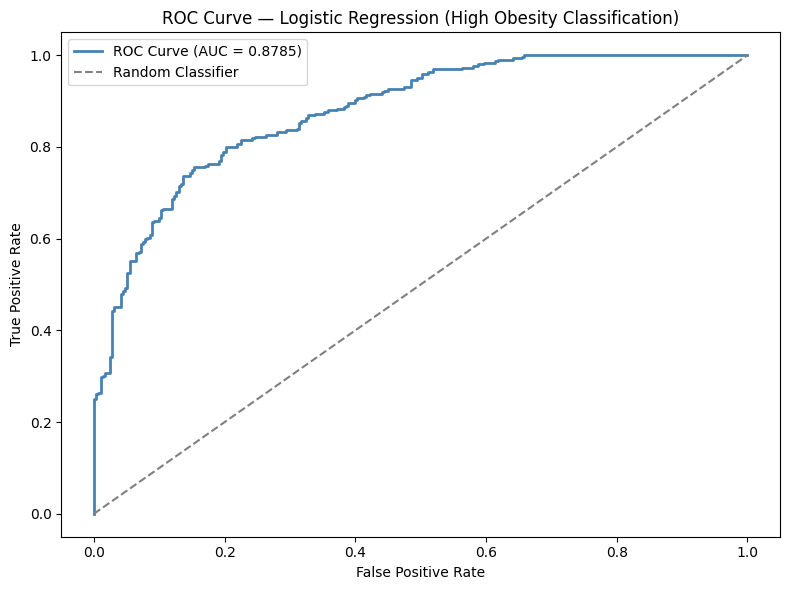

In [13]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability scores instead of just 0/1 predictions
y_prob = log_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (High Obesity Classification)')
plt.legend()
plt.tight_layout()
plt.show()

DECISION TREE/RANDOM FOREST

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Results:")
print(f"Accuracy: {dt_model.score(X_test, y_test):.4f}")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results:
Accuracy: 0.7872
              precision    recall  f1-score   support

           0       0.75      0.85      0.80       293
           1       0.83      0.73      0.78       299

    accuracy                           0.79       592
   macro avg       0.79      0.79      0.79       592
weighted avg       0.79      0.79      0.79       592



Random Forest Results:
Accuracy: 0.8159
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       293
           1       0.83      0.80      0.81       299

    accuracy                           0.82       592
   macro avg       0.82      0.82      0.82       592
weighted avg       0.82      0.82      0.82       592

               Variable  Importance
4    csmoking_crudeprev      0.2017
1         lpa_crudeprev      0.1912
3      bphigh_crudeprev      0.1212
5       sleep_crudeprev      0.1164
0    diabetes_crudeprev      0.1042
2     access2_crudeprev      0.0927
6  depression_crudeprev      0.0869
7  cholscreen_crudeprev      0.0858


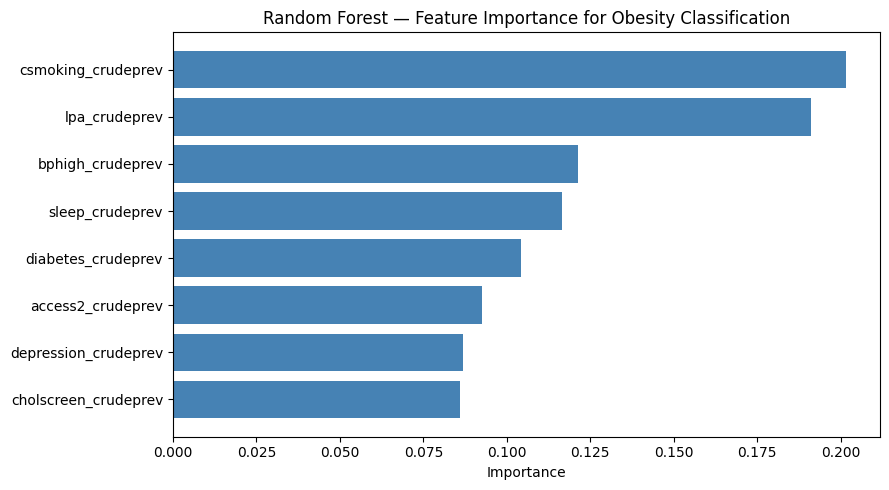

In [15]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print(f"Accuracy: {rf_model.score(X_test, y_test):.4f}")
print(classification_report(y_test, y_pred_rf))

feat_imp = pd.DataFrame({
    'Variable': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feat_imp.round(4))

plt.figure(figsize=(9, 5))
plt.barh(feat_imp['Variable'], feat_imp['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Random Forest — Feature Importance for Obesity Classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

PCA/KMEAN

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Total variance explained:  {sum(pca.explained_variance_ratio_):.4f}")


Variance explained by PC1: 0.5103
Variance explained by PC2: 0.1832
Total variance explained:  0.6935


In [19]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]
df['cluster'] = clusters
hidalgo = df[(df['stateabbr'] == 'TX') & (df['countyname'] == 'Hidalgo')]
hidalgo_pc1 = hidalgo['PC1'].values[0]
hidalgo_pc2 = hidalgo['PC2'].values[0]
hidalgo_cluster = hidalgo['cluster'].values[0]
print(f"\nHidalgo cluster: {hidalgo_cluster}")


Hidalgo cluster: 1


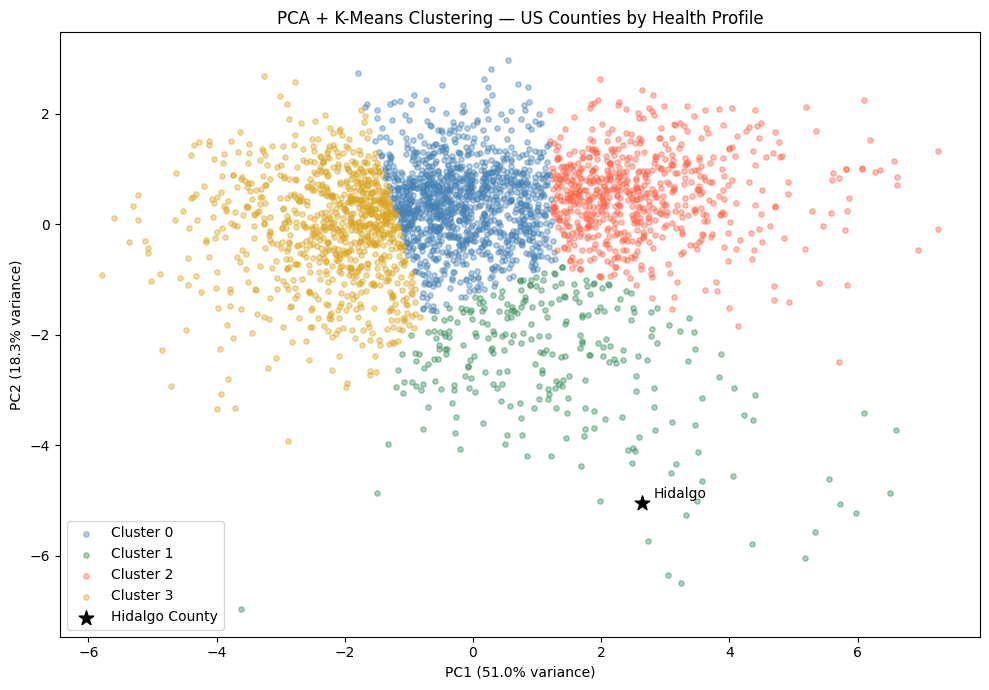

In [20]:
colors = ['steelblue', 'seagreen', 'tomato', 'goldenrod']
plt.figure(figsize=(10, 7))

for cluster_id in range(4):
    mask = df['cluster'] == cluster_id
    plt.scatter(df[mask]['PC1'], df[mask]['PC2'],
                c=colors[cluster_id], alpha=0.4, s=15,
                label=f'Cluster {cluster_id}')

plt.scatter(hidalgo_pc1, hidalgo_pc2,
            c='black', s=120, zorder=5, marker='*',
            label='Hidalgo County')
plt.annotate('Hidalgo', (hidalgo_pc1, hidalgo_pc2),
             textcoords='offset points', xytext=(8, 4), fontsize=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA + K-Means Clustering — US Counties by Health Profile')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
cluster_profiles = df.groupby('cluster')[['obesity_crudeprev', 'diabetes_crudeprev',
                                           'lpa_crudeprev', 'access2_crudeprev',
                                           'bphigh_crudeprev', 'csmoking_crudeprev']].mean()
print(cluster_profiles.round(2))

         obesity_crudeprev  diabetes_crudeprev  lpa_crudeprev  \
cluster                                                         
0                    37.76               13.49          27.99   
1                    38.57               14.50          32.34   
2                    41.81               17.10          35.04   
3                    33.16               10.86          22.66   

         access2_crudeprev  bphigh_crudeprev  csmoking_crudeprev  
cluster                                                           
0                     9.90             39.19               15.78  
1                    20.85             36.15               16.65  
2                    12.52             45.63               19.84  
3                     8.59             33.52               12.47  


Correlation

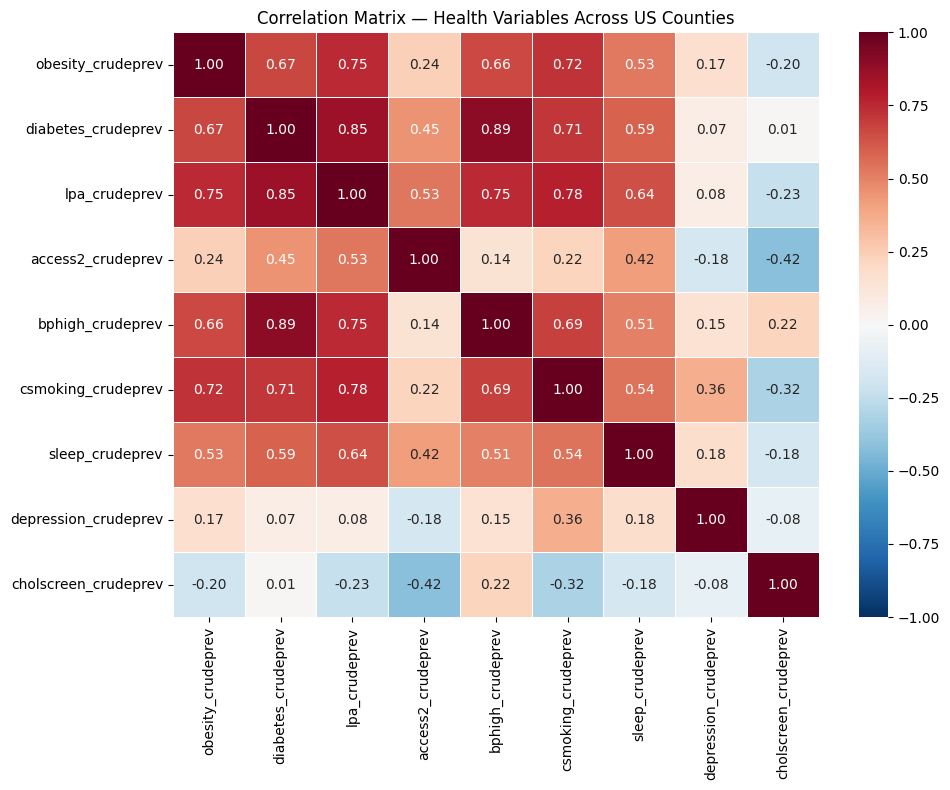

Correlations with obesity rate:
obesity_crudeprev       1.0000
lpa_crudeprev           0.7471
csmoking_crudeprev      0.7219
diabetes_crudeprev      0.6705
bphigh_crudeprev        0.6592
sleep_crudeprev         0.5258
access2_crudeprev       0.2387
depression_crudeprev    0.1715
cholscreen_crudeprev   -0.1990
Name: obesity_crudeprev, dtype: float64


In [22]:
import seaborn as sns

corr = df[['obesity_crudeprev', 'diabetes_crudeprev', 'lpa_crudeprev',
           'access2_crudeprev', 'bphigh_crudeprev', 'csmoking_crudeprev',
           'sleep_crudeprev', 'depression_crudeprev',
           'cholscreen_crudeprev']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix — Health Variables Across US Counties')
plt.tight_layout()
plt.show()

print("Correlations with obesity rate:")
print(corr['obesity_crudeprev'].sort_values(ascending=False).round(4))

MONTE CARLO

In [23]:
hidalgo_row = df[(df['stateabbr'] == 'TX') & (df['countyname'] == 'Hidalgo')][X.columns].values[0]
hidalgo_actual_obesity = df[(df['stateabbr'] == 'TX') & (df['countyname'] == 'Hidalgo')]['obesity_crudeprev'].values[0]

#Selecting variables where Hidalgo is above national average
national_means = df[X.columns].mean()
hidalgo_series = pd.Series(hidalgo_row, index=X.columns)

elevated = hidalgo_series[hidalgo_series > national_means].index.tolist()
print("Variables where Hidalgo exceeds national average:")
for v in elevated:
    print(f"  {v:<30} Hidalgo: {hidalgo_series[v]:.2f}  National avg: {national_means[v]:.2f}")

Variables where Hidalgo exceeds national average:
  diabetes_crudeprev             Hidalgo: 17.40  National avg: 13.64
  lpa_crudeprev                  Hidalgo: 37.50  National avg: 28.45
  access2_crudeprev              Hidalgo: 37.40  National avg: 11.14
  sleep_crudeprev                Hidalgo: 40.40  National avg: 35.79


In [28]:
import warnings
warnings.filterwarnings('ignore')

n_simulations = 10000
results = {}

for var in elevated:
    var_idx = list(X.columns).index(var)

    # build all 10,000 rows at once instead of one by one
    sim_matrix = np.tile(hidalgo_row.astype(float), (n_simulations, 1))
    sim_matrix[:, var_idx] = np.random.normal(df[var].mean(), df[var].std(), n_simulations)

    sim_df = pd.DataFrame(sim_matrix, columns=X.columns)
    simulated_preds = model.predict(sim_df)

    results[var] = {
        'mean':      simulated_preds.mean(),
        'ci_lower':  np.percentile(simulated_preds, 2.5),
        'ci_upper':  np.percentile(simulated_preds, 97.5),
        'reduction': simulated_preds.mean() - hidalgo_actual_obesity
    }

print(f"\nHidalgo actual obesity: {hidalgo_actual_obesity:.2f}%")
print(f"\nMonte Carlo — If each variable reduced to national average:")
print(f"{'Variable':<30} {'Predicted':>10} {'95% CI':>20} {'Reduction':>10}")
print("-" * 75)
for var, res in sorted(results.items(), key=lambda x: x[1]['reduction'], reverse=True):
    print(f"{var:<30} {res['mean']:>9.2f}%  ({res['ci_lower']:.2f}%, {res['ci_upper']:.2f}%)  {res['reduction']:>+8.2f}%")

vars_sorted = sorted(results.keys(), key=lambda x: results[x]['reduction'], reverse=True)
means       = [results[v]['mean'] for v in vars_sorted]
ci_lower    = [results[v]['mean'] - results[v]['ci_lower'] for v in vars_sorted]
ci_upper    = [results[v]['ci_upper'] - results[v]['mean'] for v in vars_sorted]
reductions  = [results[v]['reduction'] for v in vars_sorted]



Hidalgo actual obesity: 44.20%

Monte Carlo — If each variable reduced to national average:
Variable                        Predicted               95% CI  Reduction
---------------------------------------------------------------------------
access2_crudeprev                  40.50%  (39.06%, 42.00%)     -3.70%
diabetes_crudeprev                 36.67%  (36.16%, 37.18%)     -7.53%
sleep_crudeprev                    35.91%  (35.20%, 36.61%)     -8.29%
lpa_crudeprev                      32.89%  (28.74%, 36.97%)    -11.31%


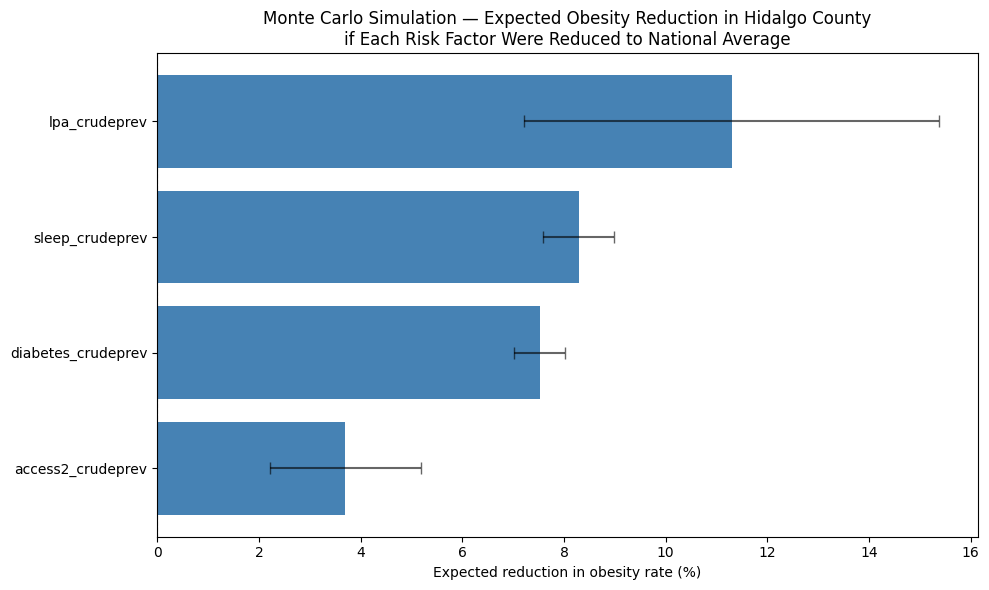

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(vars_sorted, reductions, color='steelblue', xerr=[ci_lower, ci_upper],
        error_kw={'capsize': 4, 'color': 'black', 'alpha': 0.6})
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Expected reduction in obesity rate (%)')
ax.set_title('Monte Carlo Simulation — Expected Obesity Reduction in Hidalgo County\nif Each Risk Factor Were Reduced to National Average')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Hidalgo actual obesity:          44.20%
Predicted if all 4 reduced:      37.02%
95% CI:                          (32.72%, 41.55%)
Expected change:                 -7.18%


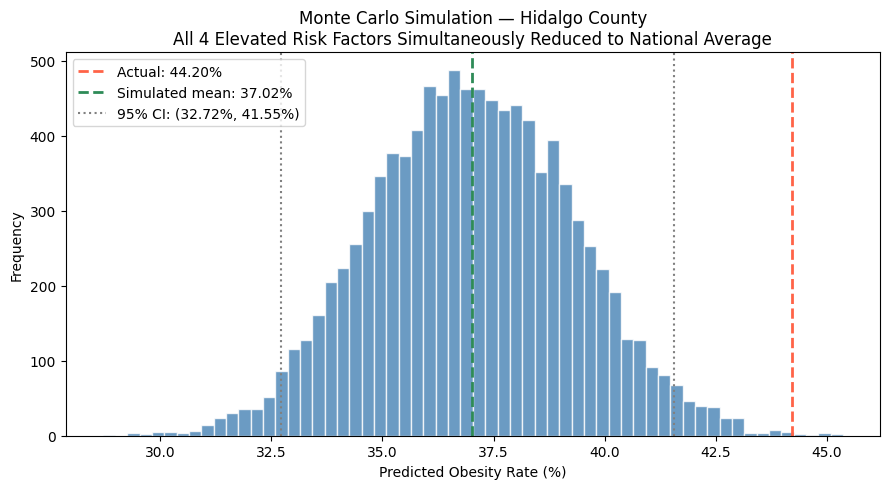

In [32]:
n_simulations = 10000

sim_matrix = np.tile(hidalgo_row.astype(float), (n_simulations, 1))

for var in elevated:
    var_idx = list(X.columns).index(var)
    sim_matrix[:, var_idx] = np.random.normal(df[var].mean(), df[var].std(), n_simulations)

sim_df = pd.DataFrame(sim_matrix, columns=X.columns)
simulated_preds = model.predict(sim_df)

mean_pred   = simulated_preds.mean()
ci_lower    = np.percentile(simulated_preds, 2.5)
ci_upper    = np.percentile(simulated_preds, 97.5)
reduction   = mean_pred - hidalgo_actual_obesity

print(f"Hidalgo actual obesity:          {hidalgo_actual_obesity:.2f}%")
print(f"Predicted if all 4 reduced:      {mean_pred:.2f}%")
print(f"95% CI:                          ({ci_lower:.2f}%, {ci_upper:.2f}%)")
print(f"Expected change:                 {reduction:.2f}%")

plt.figure(figsize=(9, 5))
plt.hist(simulated_preds, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(hidalgo_actual_obesity, color='tomato', linestyle='--', linewidth=2, label=f'Actual: {hidalgo_actual_obesity:.2f}%')
plt.axvline(mean_pred, color='seagreen', linestyle='--', linewidth=2, label=f'Simulated mean: {mean_pred:.2f}%')
plt.axvline(ci_lower, color='gray', linestyle=':', linewidth=1.5, label=f'95% CI: ({ci_lower:.2f}%, {ci_upper:.2f}%)')
plt.axvline(ci_upper, color='gray', linestyle=':', linewidth=1.5)
plt.xlabel('Predicted Obesity Rate (%)')
plt.ylabel('Frequency')
plt.title('Monte Carlo Simulation — Hidalgo County\nAll 4 Elevated Risk Factors Simultaneously Reduced to National Average')
plt.legend()
plt.tight_layout()
plt.show()